## PROJECT: HEART FAILURE MORTALITY PREDICTION

In [2]:
### Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### DATA LOADING AND EXPLORATION

In [6]:
# Import dataset
df = pd.read_csv(r'C:\Users\user\Desktop\Data science\heart_failure_clinical_records_dataset.csv')

In [7]:
# have a look at the dataset
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


#### there are no null values

In [19]:
# let's describe our data columns
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


##### Create boxplots for different columns to see which has outliers

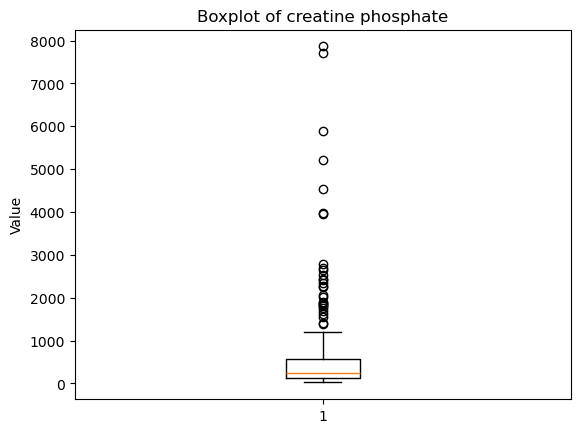

In [42]:
plt.boxplot(df['creatinine_phosphokinase'])
plt.title("Boxplot of creatinine phosphate")
plt.ylabel("Value")
plt.show;

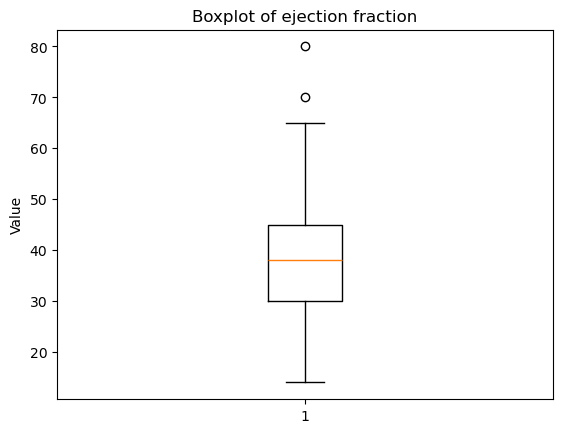

In [43]:
plt.boxplot(df['ejection_fraction'])
plt.title("Boxplot of ejection fraction")
plt.ylabel("Value")
plt.show;

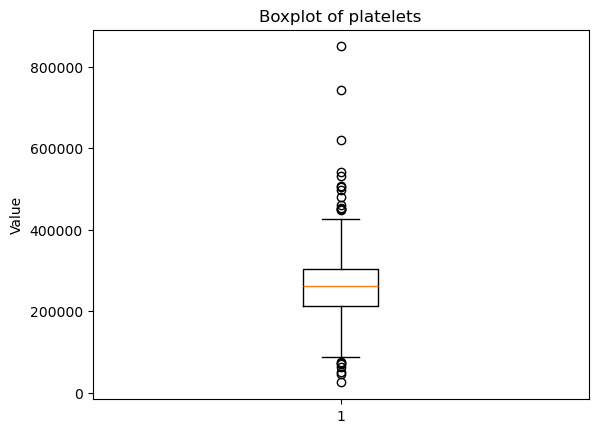

In [45]:
plt.boxplot(df['platelets'])
plt.title("Boxplot of platelets")
plt.ylabel("Value")
plt.show;

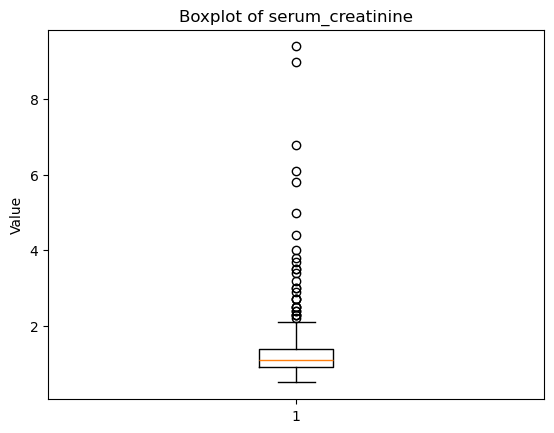

In [46]:

plt.boxplot(df['serum_creatinine'])
plt.title("Boxplot of serum_creatinine")
plt.ylabel("Value")
plt.show;

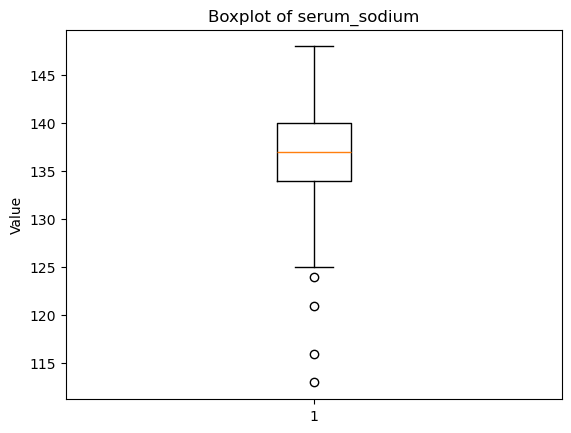

In [49]:
plt.boxplot(df['serum_sodium'])
plt.title("Boxplot of serum_sodium")
plt.ylabel("Value")
plt.show;

In [ ]:
# As can be seen from the boxplots above, there are outliers in those columns
# It is important to remove those outliers so that "special cases" will not blurr the actual trend in our data. Also,
# removing outliers will help our prediction model perform well

#### DATA CLEANING

#### Remove outliers using the interquatile range method

In [120]:
# Create a function to remove outliers
def rem_outliers(df, colname):
    q1 = np.percentile(df[colname], 25)
    q3 = np.percentile(df[colname], 75)
    IQR = q3 - q1
    lowerbound = q1 - 1.5 * IQR
    upperbound = q3 + 1.5 * IQR
    df_clean = df[(df[colname] >= lowerbound) & (df[colname] <= upperbound)]
    return df_clean

In [121]:
# Pipeline
df1 = df.copy()

##### Apply the function multiple times for each desired column

In [123]:
# Apply function
df1 = rem_outliers(df1, 'creatinine_phosphokinase')

In [125]:
df1 = rem_outliers(df1, 'ejection_fraction')

In [129]:
df1 = rem_outliers(df1, 'platelets')

In [131]:
df1 = rem_outliers(df1, 'serum_creatinine')

In [133]:
df1 = rem_outliers(df1, 'serum_sodium')

In [135]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 224 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       224 non-null    float64
 1   anaemia                   224 non-null    int64  
 2   creatinine_phosphokinase  224 non-null    int64  
 3   diabetes                  224 non-null    int64  
 4   ejection_fraction         224 non-null    int64  
 5   high_blood_pressure       224 non-null    int64  
 6   platelets                 224 non-null    float64
 7   serum_creatinine          224 non-null    float64
 8   serum_sodium              224 non-null    int64  
 9   sex                       224 non-null    int64  
 10  smoking                   224 non-null    int64  
 11  time                      224 non-null    int64  
 12  DEATH_EVENT               224 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 24.5 KB


##### We now have 224 columns

#### Feature engineering:
##### The next thing we will do is to normalize the values in our feature columns. This is important because one model we will use 
##### (logistic regression) cannot function properly without normalized values. This is called Z-score normalization or feature
##### scaling through standardization. What it does is to rescale each feature such that it has a standard deviation of 1 and a mean of 0.

In [213]:
# Import necessary module
from sklearn.preprocessing import StandardScaler

In [214]:
scaler = StandardScaler().set_output(transform="pandas")

In [215]:
# Next, split features from target variable
X = df1[['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']]
y = df1['DEATH_EVENT']

In [216]:
# Rescale (or standardize) our features using the scaler
X_rescaled = scaler.fit_transform(X)

In [220]:
X_rescaled.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,1.190537,-0.939336,0.878670,-0.850339,-1.555768,1.278786,0.136333,2.358663,-1.854716,0.745356,-0.688247,-1.683733
2,0.351568,-0.939336,-0.684634,-0.850339,-1.555768,-0.781992,-1.400896,0.524147,-2.117996,0.745356,1.452966,-1.644471
3,-0.906886,1.064581,-0.810128,-0.850339,-1.555768,-0.781992,-0.684517,2.358663,-0.011754,0.745356,-0.688247,-1.644471
5,2.448991,1.064581,-1.039604,-0.850339,0.155882,1.278786,-0.774065,2.970169,-1.328155,0.745356,1.452966,-1.631383
6,1.190537,1.064581,-0.326078,-0.850339,-1.983680,-0.781992,-1.923255,0.218395,-0.011754,0.745356,-0.688247,-1.605208


##### We will make use of these rescaled features during model development

### DATA VISUALIZATION


In [289]:
# Look at the data again
df1.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.0,1.9,130,1,0,4,1
2,65.0,0,146,0,20,0,162000.0,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.0,1.9,137,1,0,7,1
5,90.0,1,47,0,40,1,204000.0,2.1,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.0,1.2,137,1,0,10,1


In [291]:
corr_matrix = df1.corr()
corr_matrix

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
age,1.000000,0.053539,0.029417,-0.035489,0.085668,0.122613,-0.090753,0.277358,-0.024793,0.031341,-0.003437,-0.227897,0.282100
anaemia,0.053539,1.000000,-0.204293,-0.019261,-0.011293,0.021316,0.016587,-0.005744,0.073751,-0.102687,-0.148455,-0.084116,0.068454
creatinine_phosphokinase,0.029417,-0.204293,1.000000,0.000761,-0.124547,-0.014055,0.027437,0.119707,-0.121298,-0.058015,-0.058020,0.119300,0.048815
diabetes,-0.035489,-0.019261,0.000761,1.000000,0.026488,0.062085,-0.013930,-0.005966,-0.131460,-0.140246,-0.120369,0.061295,-0.032478
ejection_fraction,0.085668,-0.011293,-0.124547,0.026488,1.000000,0.058123,0.083675,-0.197565,0.169013,-0.122567,-0.084964,0.058918,-0.305454
high_blood_pressure,0.122613,0.021316,-0.014055,0.062085,0.058123,1.000000,0.083800,-0.047779,0.019875,-0.108344,-0.065429,-0.231826,0.079622
platelets,-0.090753,0.016587,0.027437,-0.013930,0.083675,0.083800,1.000000,-0.033240,0.008382,-0.132695,-0.028553,0.037306,-0.065993
serum_creatinine,0.277358,-0.005744,0.119707,-0.005966,-0.197565,-0.047779,-0.033240,1.000000,-0.216217,0.146300,-0.025052,-0.111504,0.348548
serum_sodium,-0.024793,0.073751,-0.121298,-0.131460,0.169013,0.019875,0.008382,-0.216217,1.000000,-0.050111,0.042244,0.027019,-0.112804
sex,0.031341,-0.102687,-0.058015,-0.140246,-0.122567,-0.108344,-0.132695,0.146300,-0.050111,1.000000,0.473090,0.018674,0.037374


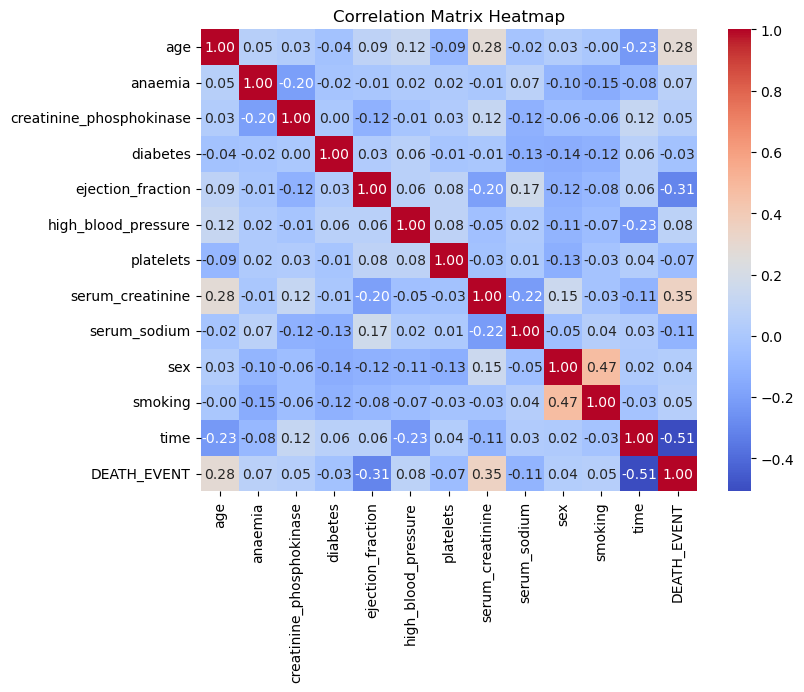

In [295]:
# Let us make this more colorful using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

##### The top most correlated features with DEATH_EVENT are: time, serum_creatinine, ejection_fraction and age
##### Let us focus our data analysis on 2 of these 4 most correlated variables (time and age).

##### Looking back at our described data, the range of values in the TIME column is very wide. Let us make a histogram of it

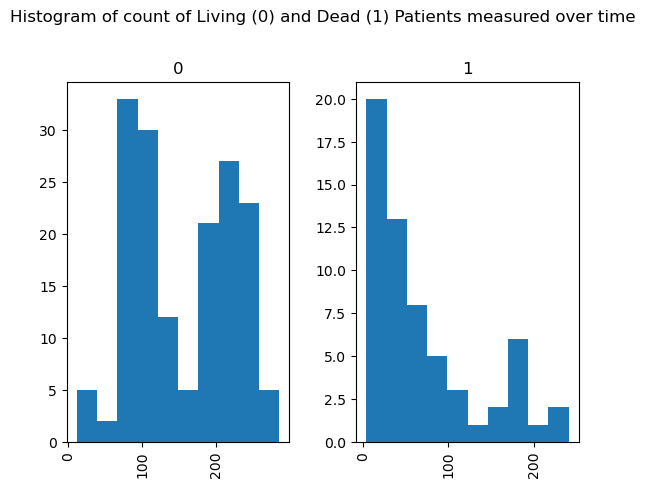

In [433]:
df1.hist(column = 'time', by = 'DEATH_EVENT', bins = 10)
plt.suptitle("Histogram of count of Living (0) and Dead (1) Patients measured over time", y=1.05) # y adjusts height to avoid overlap
plt.show;

As can be seen above, deaths are highest immediately after a heart failure event but that number reduces as time increases

##### What is the distribution of ages among dead and living patient?
##### To answer this question, let us put ages into buckets and then create two bar charts for dead or living

In [428]:
# Create a new dataframe for the desired columns
df3 = df1.loc[:, ['age','DEATH_EVENT']]

In [429]:
df3.head()

,age,DEATH_EVENT
0,75.0,1
2,65.0,1
3,50.0,1
5,90.0,1
6,75.0,1


In [430]:
# Now create the buckets for age
df3['age_grps'] = df3['age'].apply(
    lambda x: '<50' if x < 50 else ('50-65' if x < 66 else '>65'))

In [323]:
df3.head()

,age,DEATH_EVENT,age_grps
0,75.0,1,>65
2,65.0,1,50-65
3,50.0,1,50-65
5,90.0,1,>65
6,75.0,1,>65


In [385]:
# Create proportions of each age group in 0 or 1 of 'DEATH_EVENT'

In [383]:
# First, group and count
df_prop = df3.groupby(['DEATH_EVENT', 'age_grps']).size().reset_index(name='count')

# Next, divide by the sum of each age_bucket to get proportion
df_prop['proportion'] = df_prop['count'] / df_prop.groupby('DEATH_EVENT')['count'].transform('sum')

In [384]:
df_prop

,DEATH_EVENT,age_grps,count,proportion
0,0,50-65,97,0.595092
1,0,<50,28,0.171779
2,0,>65,38,0.233129
3,1,50-65,23,0.377049
4,1,<50,7,0.114754
5,1,>65,31,0.508197


C:\Users\user\AppData\Local\Temp\ipykernel_6536\3306667141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df_prop, kind='bar', x ='age_grps', y='proportion', col='DEATH_EVENT',palette="viridis")


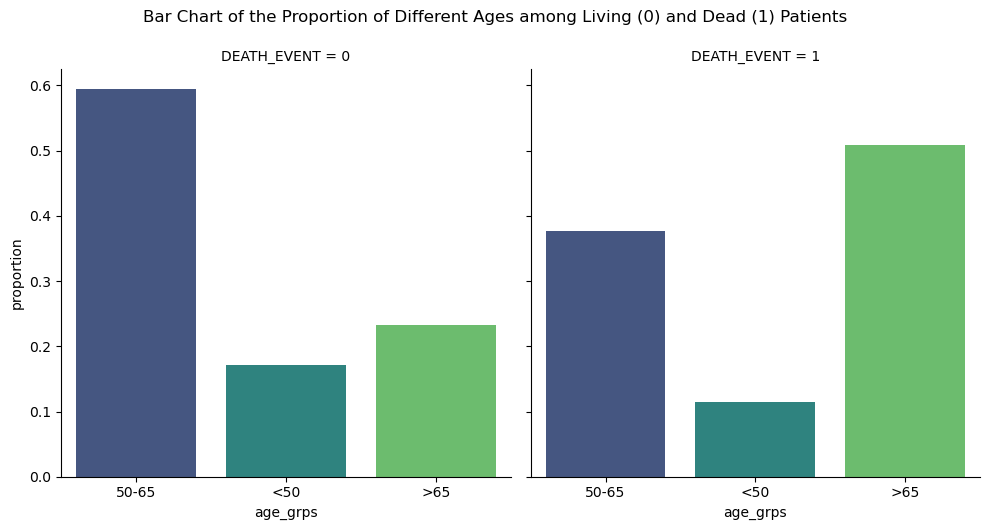

In [435]:
# Creates a separate bar chart (column) for each category in DEATH_EVENT
sns.catplot(data=df_prop, kind='bar', x ='age_grps', y='proportion', col='DEATH_EVENT',palette="viridis")
plt.suptitle("Bar Chart of the Proportion of Different Ages among Living (0) and Dead (1) Patients", y=1.05)
plt.show()

Both the <50 and 50-65 age groups form a smaller proportion of deaths than living. The >65 age group on the other hand forms a larger proportion 

#### MODEL BUILDING AND ANALYSIS

##### We will use two models, random forest and logistic regression to predict mortality following heart failure
##### Target variable: DEATH_EVENT
##### Features: every other column in the dataframe

In [232]:
# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, auc, roc_curve

In [219]:
# Create train and test sets
x_train, x_test, y_train, y_test = train_test_split(X_rescaled, y, test_size=0.2)

#### Random Forest

In [221]:
# initialize random forest model
randforest = RandomForestClassifier(n_estimators=100, random_state=1)

In [222]:
randforest.fit(x_train, y_train)

RandomForestClassifier(random_state=1)

In [223]:
# Make a prediction on unseen data
forest_pred = randforest.predict(x_test)

##### Evaluate model using different evaluation metrics

In [227]:
# Accuracy
forest_acc = accuracy_score(forest_pred, y_test)
print(f"Accuracy: {forest_acc * 100:.2f}%")

Accuracy: 80.00%


In [233]:
# F1 score
f1score = f1_score(y_test, forest_pred)
print(f"F1 Score: {f1score:.2f}")

F1 Score: 0.57


In [243]:
# For AUC and ROC curve, we need to first get the predicted probabilities and calculate true and false positive rates
probs = randforest.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)

In [248]:
#AUC
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")

AUC: 0.86


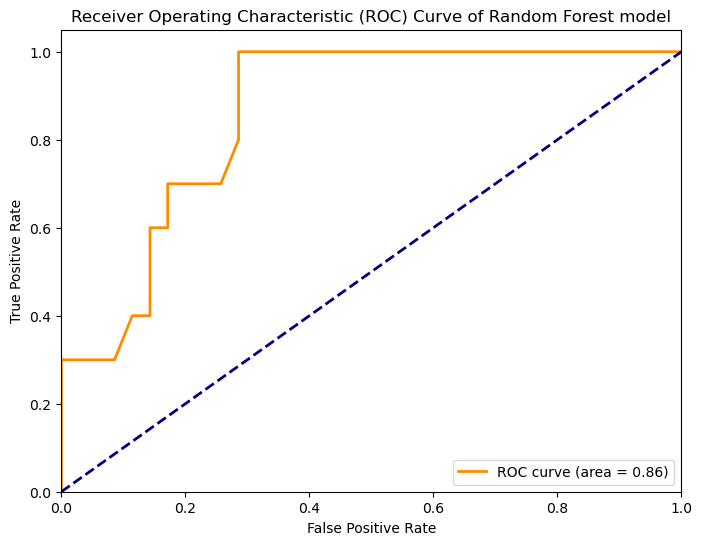

In [437]:
# Plot the ROC curve
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve of Random Forest model')
plt.legend(loc='lower right')
plt.show()

#### Logistic regression

In [281]:
# Initialise the model
logregress = LogisticRegression()

In [282]:
# Train the model
logregress.fit(x_train, y_train)

LogisticRegression()

In [283]:
# Make prediction using the trained model
log_pred = logregress.predict(x_test)

##### Evaluate model using different evaluation metrics

In [284]:
# Accuracy
log_acc = accuracy_score(log_pred, y_test)
print(f"Accuracy: {log_acc * 100:.2f}%")

Accuracy: 68.89%


In [285]:
# F1 score
f1score_log = f1_score(y_test, log_pred)
print(f"F1 Score: {f1score_log:.2f}")

F1 Score: 0.42


In [286]:
# For AUC and ROC curve, we need to first get the predicted probabilities and calculate true and false positive rates
probs_log = logregress.predict_proba(x_test)[:, 1]
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, probs_log)

In [287]:
#AUC
roc_auc_log = auc(fpr_log, tpr_log)
print(f"AUC: {roc_auc_log:.2f}")

AUC: 0.75


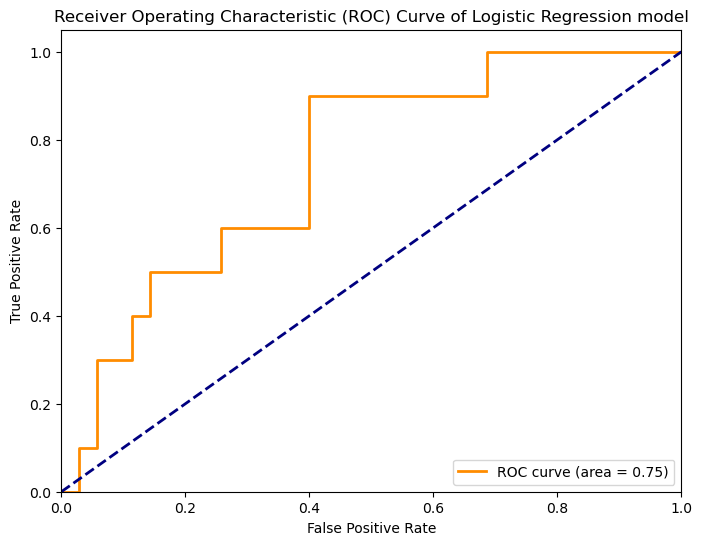

In [436]:
# Plot the ROC curve
roc_auc_log = auc(fpr_log, tpr_log)
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_log:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve of Logistic Regression model')
plt.legend(loc='lower right')
plt.show()

##### Model Comparison: Random forest vs Logistic regression

             Random forest       Logistic Regression
    Accuracy  80.00%               68.89%
    F1 score  0.57                 0.42
    AUC       0.86                 0.75

The random forest model performed better than the loistic reression model.

#### Model Selection and Testing Report

##### Why the chosen models were selected:
The models used in this project were selected for two reasons:
1) They are both suitable for classification tasks as their outputs are categorical, not continuous. 
2) They have fundamentally different architectures thus enabling comparism of how different machine learning algorithms would perform
    on our data. Random forest is an ensemble learning algorithm that uses multiple decision trees to produce an output while 
    logistic regression attempts to fit a function to the data in an attempt to make predictions on new data. 

##### What worked and what failed
What Worked: the models achieved satisfactory to good performance in predicting mortality following heart failure. The random forest model 
   achieved an AUC of 0.86 while the logistic regression achieved 0.75. The accuracy of the RF and LR were respectively 80% and 68.89%. Their F1
   scores were 0.57 and 0.42   Although they both had satisfactory performance, the random forest performed better.
   It is also noteworthy that for the logistic regression to work on data, it generally needs to be normalized (with mean 0 and standard deviation
   of 1). Otherwise, it may fail to converge during traning and be unable to fit to the data, thus producing poor prediction results. The random 
   forest does not generally need to have its input data normalized, although it can work with normalized data as well.

What Failed: The models' performance has room for improvement. For example, an excellent F1 score needs to be close to 1.0 but the best model in 
   this project had an F1 score of only 0.56. This may have been because the dataset was relatively small. It is expected that these models would both
   perform significantly better in the future if a larger dataset is provided.
   Also, while working with the logistic regression model, different model hyperparameters were tested (solver as 'lbfgs' vs 'liblinear') but both
   produced the same performance result. It is possible that the bottleneck was not the model hyperparameters but the size of the input data that
   constrained performance.